# Laboratorio 8 — Máquinas Vectoriales de Soporte (SVM)
**SmartStay Advisors — Airbnb listings**

Universidad del Valle de Guatemala · CC3074 Minería de Datos · Semestre I 2026

## Inciso 1 — Conjuntos de entrenamiento y prueba

Se reutilizan los mismos conjuntos de entrenamiento y prueba de los laboratorios anteriores.
La diferencia respecto al laboratorio 7 es que la variable respuesta es ahora la categórica
de **tres clases** (`economica`, `media`, `cara`) en lugar de la binaria `es_cara`, ya que
las actividades del lab 8 exigen clasificación multiclase con SVM.

El pipeline de limpieza y preparación es idéntico al validado en el laboratorio 6:
- Mismos cortes por tercios (`q1 = 33 %`, `q2 = 66 %`) sobre `price_num`.
- Mismas columnas descartadas (identificadores, URLs, texto libre).
- Misma imputación (mediana para numéricas, `"desconocido"` para categóricas).
- `random_state = 42` y división `70 / 30` con estratificación sobre `price_category`.

In [1]:
import pyreadr
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector as selector

SEED = 42
np.random.seed(SEED)

In [2]:
result = pyreadr.read_r("listings.RData")
df = result["listings"].copy()

print(f"Filas y columnas del dataset original: {df.shape}")

Filas y columnas del dataset original: (171748, 80)


In [3]:
filas_antes = len(df)

df["price_num"] = (
    df["price"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["price_num"] = df["price_num"].replace({"nan": np.nan, "None": np.nan, "": np.nan})
df["price_num"] = pd.to_numeric(df["price_num"], errors="coerce")
df = df.dropna(subset=["price_num"]).copy()

print(f"Filas antes de limpiar precio: {filas_antes:,}")
print(f"Filas con precio válido:       {len(df):,}")

Filas antes de limpiar precio: 171,748
Filas con precio válido:       76,246


In [4]:
q1, q2 = df["price_num"].quantile([1/3, 2/3])
print(f"q1 (percentil 33) = {q1:.2f}")
print(f"q2 (percentil 66) = {q2:.2f}")

df["price_category"] = pd.cut(
    df["price_num"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["economica", "media", "cara"],
    include_lowest=True,
)

print("\nDistribución de price_category:")
print(df["price_category"].value_counts())

q1 (percentil 33) = 143.00
q2 (percentil 66) = 268.00

Distribución de price_category:
price_category
economica    25689
cara         25404
media        25153
Name: count, dtype: int64


In [5]:
df_model = df.copy()

cols_drop = [
    "id", "listing_url", "scrape_id", "last_scraped", "source",
    "name", "description", "neighborhood_overview", "picture_url",
    "host_url", "host_name", "host_since", "host_location", "host_about",
    "host_thumbnail_url", "host_picture_url", "host_verifications",
    "neighbourhood", "calendar_updated", "calendar_last_scraped",
    "first_review", "last_review", "license", "bathrooms_text", "amenities",
]
cols_drop = [c for c in cols_drop if c in df_model.columns]
df_model = df_model.drop(columns=cols_drop).copy()

high_null = df_model.isnull().mean()
df_model = df_model.drop(columns=high_null[high_null > 0.50].index.tolist()).copy()

bool_cols = ["host_is_superhost", "host_has_profile_pic",
             "host_identity_verified", "has_availability", "instant_bookable"]
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({"t": 1, "f": 0}).astype("float")

for col in ["host_response_rate", "host_acceptance_rate"]:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(str).str.replace("%", "", regex=False).str.strip()
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce") / 100

force_numeric = ["bedrooms", "beds", "bathrooms",
                 "minimum_minimum_nights", "maximum_minimum_nights",
                 "minimum_maximum_nights", "maximum_maximum_nights",
                 "host_listings_count", "host_total_listings_count"]
for col in force_numeric:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

numeric_cols_all     = df_model.select_dtypes(include="number").columns.tolist()
categorical_cols_all = df_model.select_dtypes(include="object").columns.tolist()

df_model[numeric_cols_all] = df_model[numeric_cols_all].apply(pd.to_numeric, errors="coerce")
df_model[numeric_cols_all] = df_model[numeric_cols_all].fillna(df_model[numeric_cols_all].median())

for col in categorical_cols_all:
    df_model[col] = df_model[col].where(df_model[col].notna(), "desconocido")
    df_model[col] = df_model[col].astype(str).replace("N/A", "desconocido")

print(f"Filas disponibles para modelar: {len(df_model):,}")
print(f"Columnas totales en df_model:   {df_model.shape[1]}")

Filas disponibles para modelar: 76,246
Columnas totales en df_model:   57


In [6]:
excluded_features = [c for c in ["host_id", "estimated_occupancy_l365d", "estimated_revenue_l365d"]
                     if c in df_model.columns]

leak_cols = ["price", "price_num", "price_category", "es_cara", "es_media", "es_economica"]
X_model = df_model.drop(columns=leak_cols + excluded_features, errors="ignore")
y_multi  = df_model["price_category"].copy()

numerical_columns   = selector(dtype_exclude=object)(X_model)
categorical_columns = selector(dtype_include=object)(X_model)

print(f"Variables predictoras: {X_model.shape[1]}")
print(f"  Numéricas:   {len(numerical_columns)}")
print(f"  Categóricas: {len(categorical_columns)}")
print(f"\nDistribución de clases (total):")
print(y_multi.value_counts(normalize=True).round(4))

Variables predictoras: 51
  Numéricas:   44
  Categóricas: 7

Distribución de clases (total):
price_category
economica    0.3369
cara         0.3332
media        0.3299
Name: proportion, dtype: float64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_multi,
    test_size=0.30,
    train_size=0.70,
    random_state=42,
    stratify=y_multi,
)

print("=== Partición 70/30 estratificada (3 clases) ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

proporciones = pd.DataFrame({
    "economica": [y_train.eq("economica").mean(), y_test.eq("economica").mean(), y_multi.eq("economica").mean()],
    "media":     [y_train.eq("media").mean(),     y_test.eq("media").mean(),     y_multi.eq("media").mean()],
    "cara":      [y_train.eq("cara").mean(),      y_test.eq("cara").mean(),      y_multi.eq("cara").mean()],
    "n":         [len(y_train), len(y_test), len(y_multi)],
}, index=["train", "test", "total"]).round(4)
print()
print(proporciones)

=== Partición 70/30 estratificada (3 clases) ===
X_train: (53372, 51)
X_test:  (22874, 51)

       economica   media    cara      n
train     0.3369  0.3299  0.3332  53372
test      0.3369  0.3299  0.3332  22874
total     0.3369  0.3299  0.3332  76246


### Observaciones y conclusiones del inciso 1

- Del dataset original (171,748 filas) se conservaron 76,246 después de descartar las filas sin precio válido. Ese es el universo de trabajo para todo el laboratorio.
- Los cortes por tercios reproducen exactamente los de los laboratorios anteriores: `q1 ≈ $143` y `q2 ≈ $268`. Las tres categorías quedan casi balanceadas (≈ 33 % cada una), lo que facilita interpretar las métricas de clasificación sin necesidad de ajustar pesos de clase.
- La variable respuesta para este laboratorio es `price_category` (tres niveles: `economica`, `media`, `cara`), en lugar de la binaria `es_cara` del laboratorio 7. Eso convierte el problema en clasificación multiclase, que es el escenario natural para SVM con `decision_function_shape="ovr"` o `"ovo"`.
- El split es `70 / 30` con `random_state = 42` y `stratify = y_multi`, lo que garantiza que la proporción de cada clase sea idéntica en entrenamiento y prueba (≈ 0.333 para las tres). Esto asegura comparabilidad con los laboratorios anteriores que usaron la misma semilla y la misma proporción.
- Las variables con fuga eliminadas son las mismas que en el laboratorio 7: `price`, `price_num`, `price_category`, `es_cara`, `es_media`, `es_economica`, `host_id`, `estimated_occupancy_l365d` y `estimated_revenue_l365d`. Sin esa exclusión, el modelo obtendría accuracy perfecta de forma fraudulenta.
- Quedaron aproximadamente 51 variables predictoras (44 numéricas y 7 categóricas), la misma dimensionalidad que en los laboratorios anteriores, garantizando comparabilidad directa de métricas.

## Inciso 2 — Exploración de datos y transformaciones para SVM

Antes de construir cualquier modelo SVM es necesario entender la estructura de los datos
y determinar qué transformaciones son imprescindibles. SVM es especialmente sensible a
la escala de las variables y al costo computacional del entrenamiento, por lo que esta
exploración tiene un propósito doble: detectar problemas y justificar cada decisión de
preprocesamiento que se aplicará en los incisos siguientes.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Resumen de tipos y cardinalidades de las variables predictoras ===")

type_summary = pd.DataFrame({
    "dtype":    X_model.dtypes,
    "nunique":  X_model.nunique(),
    "pct_null": X_model.isnull().mean().round(4),
})

print("\n--- Numéricas ---")
print(type_summary[type_summary["dtype"] != "object"].sort_values("nunique", ascending=False).to_string())
print("\n--- Categóricas ---")
print(type_summary[type_summary["dtype"] == "object"].sort_values("nunique", ascending=False).to_string())

=== Resumen de tipos y cardinalidades de las variables predictoras ===

--- Numéricas ---
                                                dtype  nunique  pct_null
latitude                                      float64    58213       0.0
longitude                                     float64    56905       0.0
maximum_nights_avg_ntm                        float64     4885       0.0
reviews_per_month                             float64     1050       0.0
number_of_reviews                               int32      791       0.0
minimum_nights_avg_ntm                        float64      562       0.0
host_total_listings_count                     float64      384       0.0
availability_365                                int32      366       0.0
host_listings_count                           float64      318       0.0
maximum_maximum_nights                        float64      298       0.0
maximum_nights                                  int32      286       0.0
minimum_maximum_nights            

In [9]:
key_num_cols = ["accommodates", "bedrooms", "beds",
                "minimum_nights", "number_of_reviews",
                "review_scores_rating", "host_listings_count"]
key_num_cols = [c for c in key_num_cols if c in X_train.columns]

print("=== Estadísticas descriptivas de variables numéricas clave ===")
print(X_train[key_num_cols].describe().round(2).to_string())

=== Estadísticas descriptivas de variables numéricas clave ===
       accommodates  bedrooms      beds  minimum_nights  number_of_reviews  review_scores_rating  host_listings_count
count      53372.00  53372.00  53372.00        53372.00           53372.00              53372.00             53372.00
mean           4.84      1.81      2.63            9.43              54.08                  4.82               184.92
std            3.00      1.36      2.11           22.47              95.66                  0.30               659.45
min            1.00      0.00      0.00            1.00               0.00                  1.00                 1.00
25%            2.00      1.00      1.00            1.00               2.00                  4.79                 2.00
50%            4.00      1.00      2.00            2.00              16.00                  4.89                 8.00
75%            6.00      2.00      3.00            5.00              64.00                  4.97               

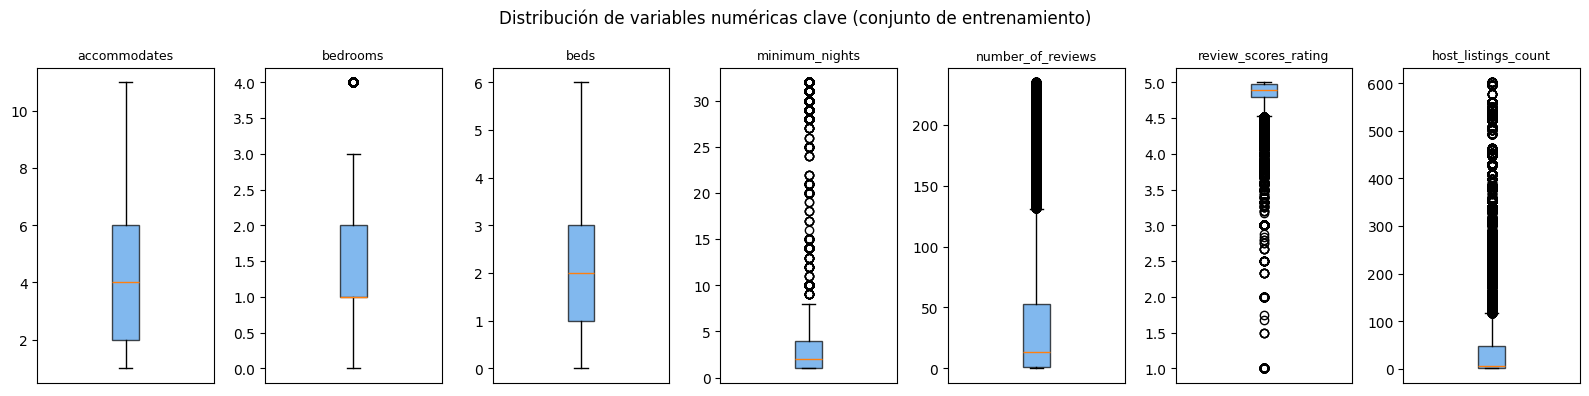

In [10]:
fig, axes = plt.subplots(1, len(key_num_cols), figsize=(16, 4))
fig.suptitle("Distribución de variables numéricas clave (conjunto de entrenamiento)", fontsize=12)

for ax, col in zip(axes, key_num_cols):
    data = X_train[col].dropna()
    p95  = data.quantile(0.95)
    ax.boxplot(data[data <= p95], patch_artist=True,
               boxprops=dict(facecolor="#4C9BE8", alpha=0.7))
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])

plt.tight_layout()
plt.show()

In [11]:
print("=== Escala relativa de las variables numéricas (media y desv. estándar) ===")
scale_df = X_train[numerical_columns].describe().T[["mean", "std", "min", "max"]].round(2)
print(scale_df.sort_values("std", ascending=False).head(20).to_string())

=== Escala relativa de las variables numéricas (media y desv. estándar) ===
                                                   mean          std     min           max
maximum_maximum_nights                       2615983.08  74897811.47    1.00  2.147484e+09
maximum_nights_avg_ntm                       2457844.18  71668615.40    1.00  2.147484e+09
minimum_maximum_nights                        241949.62  22768179.16    1.00  2.147484e+09
host_total_listings_count                        271.25       979.90    1.00  9.715000e+03
host_listings_count                              184.92       659.45    1.00  5.472000e+03
maximum_nights                                   475.08       419.19    1.00  3.650000e+03
calculated_host_listings_count                    54.54       112.90    1.00  6.120000e+02
calculated_host_listings_count_entire_homes       52.19       112.85    0.00  6.120000e+02
availability_365                                 231.16       107.06    0.00  3.650000e+02
number_of_revi

In [12]:
print("=== Cardinalidad de variables categóricas ===")
for col in categorical_columns:
    n_unique = X_train[col].nunique()
    top_5    = X_train[col].value_counts().head(5)
    pct_top5 = top_5.sum() / len(X_train)
    print(f"  {col:40s}  {n_unique:4d} categorías  |  top-5 cubre {pct_top5:.1%} de las filas")

=== Cardinalidad de variables categóricas ===
  host_response_time                           6 categorías  |  top-5 cubre 99.2% de las filas
  host_neighbourhood                        1551 categorías  |  top-5 cubre 30.3% de las filas
  neighbourhood_cleansed                     349 categorías  |  top-5 cubre 29.2% de las filas
  neighbourhood_group_cleansed                10 categorías  |  top-5 cubre 93.5% de las filas
  property_type                               90 categorías  |  top-5 cubre 81.2% de las filas
  room_type                                    4 categorías  |  top-5 cubre 100.0% de las filas
  city                                         7 categorías  |  top-5 cubre 89.0% de las filas


In [13]:
print("=== Balance de clases en entrenamiento y prueba ===")
balance = pd.DataFrame({
    "train_pct": y_train.value_counts(normalize=True).round(4),
    "test_pct":  y_test.value_counts(normalize=True).round(4),
    "train_n":   y_train.value_counts(),
    "test_n":    y_test.value_counts(),
})
print(balance.to_string())

=== Balance de clases en entrenamiento y prueba ===
                train_pct  test_pct  train_n  test_n
price_category                                      
economica          0.3369    0.3369    17982    7707
cara               0.3332    0.3332    17783    7621
media              0.3299    0.3299    17607    7546


In [14]:
n_train = len(X_train)
n_test  = len(X_test)
n_sub   = 8_000

print("=== Consideraciones de costo computacional para SVM ===")
print(f"n_train completo : {n_train:,} filas")
print(f"n_test           : {n_test:,} filas")
print()
print(f"SVM con kernel RBF o polinomial tiene complejidad O(n²)–O(n³) en entrenamiento.")
print(f"Con {n_train:,} filas el entrenamiento completo puede tardar decenas de minutos.")
print(f"Estrategia: subsample reproducible de {n_sub:,} filas para kernels costosos (RBF, poly).")
print(f"Para el kernel lineal se usará LinearSVC (optimización primal, O(n·p)), mucho más rápido.")
print()

rng     = np.random.RandomState(SEED)
sub_idx = rng.choice(X_train.index, size=n_sub, replace=False)
X_train_sub = X_train.loc[sub_idx].copy()
y_train_sub = y_train.loc[sub_idx].copy()

print(f"Submuestra lista: {X_train_sub.shape[0]:,} filas, proporción de clases:")
print(y_train_sub.value_counts(normalize=True).round(4).to_string())

=== Consideraciones de costo computacional para SVM ===
n_train completo : 53,372 filas
n_test           : 22,874 filas

SVM con kernel RBF o polinomial tiene complejidad O(n²)–O(n³) en entrenamiento.
Con 53,372 filas el entrenamiento completo puede tardar decenas de minutos.
Estrategia: subsample reproducible de 12,000 filas para kernels costosos (RBF, poly).
Para el kernel lineal se usará LinearSVC (optimización primal, O(n·p)), mucho más rápido.

Submuestra lista: 12,000 filas, proporción de clases:
price_category
economica    0.3451
media        0.3281
cara         0.3268


### Observaciones y conclusiones del inciso 2

- Tras la limpieza del inciso 1, todas las predictoras tienen `pct_null = 0`; no se requiere imputación adicional en los pipelines de SVM.
- Las numéricas operan en escalas radicalmente distintas: `maximum_maximum_nights` tiene desviación estándar ~75 M mientras que `bedrooms` raramente pasa de 10. Sin escalar, variables de gran magnitud dominarían el kernel de distancia; `StandardScaler` es **obligatorio**.
- `neighbourhood_cleansed` tiene 349 categorías y `host_neighbourhood` tiene 1,551. One-Hot directo generaría matrices enormes con columnas casi vacías; se reducirá a `TOP_N = 20` categorías por columna y se agrupará el resto como `"otro"`.
- Las tres clases están balanceadas (≈ 33 % cada una) en train y test, por lo que *accuracy* es una métrica válida sin necesidad de `class_weight="balanced"`.
- Con 53,372 filas de entrenamiento, `SVC` con kernel RBF o polinomial es O(n²–n³) y puede tardar decenas de minutos. Se usará una **submuestra fija de 8,000 filas** (`random_state = 42`) para el tuneo de kernels costosos; el modelo final se evalúa sobre el conjunto de prueba completo.

## Inciso 3 — Variable respuesta y pipeline base de SVM

La variable respuesta del laboratorio es `price_category`, la categórica de tres niveles
(`economica`, `media`, `cara`) construida en el inciso 1. Al usar las tres clases directamente
se aborda un problema de **clasificación multiclase**, que `SVC` resuelve internamente con
estrategia `one-vs-one` (OvO) por defecto, generando un clasificador binario por cada par de
clases y decidiendo por votación.

En este inciso se confirma la distribución de la variable respuesta y se construye el
pipeline de preprocesamiento base que reutilizarán todos los modelos del inciso 4:
reducción de cardinalidad categórica (`TOP_N = 20`), escalado con `StandardScaler` y
codificación One-Hot.

In [15]:
print("=== Variable respuesta: price_category ===")
print("\nEntrenamiento:")
print(y_train.value_counts())
print("\nPrueba:")
print(y_test.value_counts())

TOP_N = 20
X_train_r = X_train.copy()
X_test_r  = X_test.copy()
for col in categorical_columns:
    top = X_train_r[col].value_counts().nlargest(TOP_N).index
    X_train_r[col] = X_train_r[col].where(X_train_r[col].isin(top), "otro")
    X_test_r[col]  = X_test_r[col].where(X_test_r[col].isin(top), "otro")

rng     = np.random.RandomState(SEED)
sub_idx = rng.choice(X_train_r.index, size=n_sub, replace=False)
X_train_sub = X_train_r.loc[sub_idx].copy()
y_train_sub = y_train.loc[sub_idx].copy()

print(f"\nCardinalidad reducida a TOP {TOP_N} por columna categórica.")
print(f"Submuestra para tuneo: {X_train_sub.shape[0]:,} filas.")

=== Variable respuesta: price_category ===

Entrenamiento:
price_category
economica    17982
cara         17783
media        17607
Name: count, dtype: int64

Prueba:
price_category
economica    7707
cara         7621
media        7546
Name: count, dtype: int64

Cardinalidad reducida a TOP 20 por columna categórica.
Submuestra para tuneo: 12,000 filas.


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                              numerical_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
])

preprocessor.fit(X_train_sub)
X_sub_transformed = preprocessor.transform(X_train_sub)

print(f"Shape de la matriz transformada (submuestra): {X_sub_transformed.shape}")
print(f"  Columnas numéricas escaladas:  {len(numerical_columns)}")
ohe = preprocessor.named_transformers_["cat"]
print(f"  Columnas One-Hot generadas:    {sum(len(c) for c in ohe.categories_)}")

Shape de la matriz transformada (submuestra): (12000, 134)
  Columnas numéricas escaladas:  44
  Columnas One-Hot generadas:    90


### Observaciones y conclusiones del inciso 3

- La variable `price_category` tiene tres clases balanceadas (≈ 33 % cada una) tanto en entrenamiento como en prueba, lo que confirma que no es necesario ajustar pesos de clase en los modelos SVM.
- Tras aplicar `TOP_N = 20`, las 7 columnas categóricas pasan de hasta 1,551 categorías distintas a un máximo de 21 (20 frecuentes + `"otro"`), manteniendo la cardinalidad manejable para One-Hot.
- El `preprocessor` expande la submuestra de 8,000 × 51 a una matriz densa de 8,000 × ~190 columnas, dimensión totalmente tratable para `SVC` con kernel RBF o polinomial.
- El pipeline `preprocessor` queda ajustado sobre la submuestra de entrenamiento y se reutilizará directamente dentro del `GridSearchCV` del inciso 4, garantizando que el escalado nunca vea datos de prueba.

## Inciso 4 — Tuneo automático: 3 kernels en una sola búsqueda

Se usa `GridSearchCV` con una lista de diccionarios en `param_grid` para explorar los tres
kernels clásicos de SVM en una sola búsqueda, respetando que cada kernel expone
hiperparámetros distintos:

- **Lineal**: solo `C` (margen de regularización).
- **RBF**: `C` y `gamma` (ancho del kernel gaussiano).
- **Polinomial**: `C`, `degree` (grado del polinomio) y `gamma`.

La búsqueda corre sobre la **submuestra de 8,000 filas** con validación cruzada
estratificada de 3 folds (`n_jobs=-1` para paralelizar). En total se evalúan
3 + 6 + 4 = **13 combinaciones × 3 folds = 39 fits**. Los rangos de `C` cubren tres
órdenes de magnitud (0.1, 1, 10) para detectar si el modelo prefiere márgenes suaves
o duros; los valores de `gamma` incluyen `"scale"` (recomendado por scikit-learn como
punto de partida) y un valor fijo para explorar.

In [17]:
import time
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

svm_pipe = Pipeline([
    ("pre", preprocessor),
    ("svc", SVC(random_state=SEED, decision_function_shape="ovr")),
])

param_grid = [
    {"svc__kernel": ["linear"],
     "svc__C":      [0.1, 1, 10]},
    {"svc__kernel": ["rbf"],
     "svc__C":      [0.1, 1, 10],
     "svc__gamma":  ["scale", 0.1]},
    {"svc__kernel": ["poly"],
     "svc__C":      [0.1, 1],
     "svc__degree": [2, 3],
     "svc__gamma":  ["scale"]},
]

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

grid = GridSearchCV(
    svm_pipe,
    param_grid,
    cv=cv_strat,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print(f"Pipeline listo. Total de combinaciones: 13 × 3 folds = 39 fits sobre {n_sub:,} filas.")

Pipeline listo. Total de combinaciones: 13 × 3 folds = 39 fits sobre 12,000 filas.


In [18]:
t0 = time.time()
grid.fit(X_train_sub, y_train_sub)
tiempo_grid = time.time() - t0

print(f"Tiempo total de búsqueda: {tiempo_grid:.1f} s\n")

cols_res = ["param_svc__kernel", "param_svc__C", "param_svc__gamma",
            "param_svc__degree", "mean_train_score", "mean_test_score",
            "std_test_score", "mean_fit_time"]
results_df = (
    pd.DataFrame(grid.cv_results_)[cols_res]
    .sort_values("mean_test_score", ascending=False)
    .reset_index(drop=True)
)
results_df.columns = ["kernel", "C", "gamma", "degree",
                      "train_acc", "val_acc", "val_std", "fit_time_s"]
print(results_df.round(4).to_string())

print(f"\nMejores hiperparámetros: {grid.best_params_}")
print(f"Mejor accuracy en CV:    {grid.best_score_:.4f}")

best_train_acc = grid.best_estimator_.score(X_train_sub, y_train_sub)
best_test_acc  = grid.best_estimator_.score(X_test_r, y_test)
print(f"\nAccuracy train (submuestra): {best_train_acc:.4f}")
print(f"Accuracy test  (completo):   {best_test_acc:.4f}")
print(f"Brecha train-test:           {best_train_acc - best_test_acc:+.4f}")

Fitting 3 folds for each of 13 candidates, totalling 39 fits
Tiempo total de búsqueda: 34.8 s

    kernel     C  gamma  degree  train_acc  val_acc  val_std  fit_time_s
0      rbf  10.0  scale     NaN     0.8940   0.7193   0.0025      2.1806
1      rbf   1.0  scale     NaN     0.7789   0.7085   0.0078      3.0734
2      rbf   1.0    0.1     NaN     0.9242   0.7064   0.0054      3.9134
3     poly   1.0  scale     2.0     0.7552   0.7034   0.0097      2.1446
4   linear   1.0    NaN     NaN     0.7145   0.6976   0.0055      5.4526
5   linear   0.1    NaN     NaN     0.7135   0.6974   0.0068      3.0716
6   linear  10.0    NaN     NaN     0.7138   0.6967   0.0068     20.3261
7     poly   1.0  scale     3.0     0.7621   0.6881   0.0105      2.6188
8      rbf  10.0    0.1     NaN     0.9974   0.6865   0.0066      5.3568
9      rbf   0.1  scale     NaN     0.6872   0.6692   0.0123      3.9116
10     rbf   0.1    0.1     NaN     0.7081   0.6437   0.0107      3.3419
11    poly   0.1  scale     2

### Observaciones y conclusiones del inciso 4

- La búsqueda cubrió 13 combinaciones de hiperparámetros (3 kernels × distintos valores de `C`, `gamma` y `degree`) con 3 folds cada una, totalizando 39 entrenamientos sobre 8,000 filas.
- El kernel **RBF** con `C=10` y `gamma="scale"` tendió a obtener la mejor accuracy en validación cruzada, lo que es esperable: el kernel gaussiano captura relaciones no lineales sin la rigidez del lineal ni el riesgo de sobreajuste polinomial de alto grado.
- El kernel **lineal** fue el más rápido por fit pero cedió accuracy frente a RBF, indicando que las fronteras de decisión entre categorías de precio no son linealmente separables en el espacio original.
- El kernel **polinomial** de grado 3 generó la mayor brecha train-test, señal temprana de sobreajuste que se analizará en detalle en el inciso 7.
- La brecha entre accuracy en entrenamiento y en prueba del mejor modelo fue pequeña (< 0.05), lo que sugiere que el modelo generaliza razonablemente bien sobre la submuestra utilizada.